# Experimento 02 — Two Moons: implementação manual vs. Keras

**Objetivo:** Implementar uma rede neural *na mão* para o dataset Two Moons e comparar com uma versão equivalente usando Keras.

**Arquitetura:** `[2 → 4 → 1]` — tanh na camada oculta, sigmoide na saída, com bias.

## 1. Diagrama da rede

A figura mostra a arquitetura implementada: `[2 → 4 → 1]` — tanh na camada oculta, sigmoide na saída, com bias.

![Diagrama da rede neural para Two Moons](rede_neural.png)

## 2. Dataset

O dataset Two Moons foi gerado com `sklearn.datasets.make_moons(n_samples=100, noise=0.1, random_state=42)` — mesma configuração do `exemplo4.py`. Duas meias-luas entrelaçadas, não linearmente separáveis.

![Dataset Two Moons](two_moons_dataset.png)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# Dataset Two Moons (mesma configuração do exemplo4.py)
X, y = datasets.make_moons(n_samples=100, noise=0.1, random_state=42)
y = y.reshape(-1, 1).astype(float)

print("X.shape =", X.shape)
print("y.shape =", y.shape)

X.shape = (100, 2)
y.shape = (100, 1)


## 3. Hiperparâmetros e arquitetura

- Entrada: 2 · Camada oculta: 4 · Saída: 1
- Taxa de aprendizado: `lr = 0.1`
- Épocas: 10000

In [2]:
# Dimensoes
n_inputs = 2
n_hidden = 4
n_outputs = 1

# Hiperparâmetros
lr = 0.1         # taxa de aprendizado
epochs = 10000   # número de épocas

print(f"Arquitetura: [{n_inputs} -> {n_hidden} -> {n_outputs}]")
print(f"Taxa de aprendizado: {lr}")
print(f"Épocas: {epochs}")

Arquitetura: [2 -> 4 -> 1]
Taxa de aprendizado: 0.1
Épocas: 10000


## 4. Funções de ativação e suas derivadas

Camada oculta — **tanh**:

$$\tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}} \qquad \tanh'(z) = 1 - \tanh(z)^2$$

Camada de saída — **sigmoide**:

$$\sigma(z) = \frac{1}{1 + e^{-z}} \qquad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

Nas implementações, as derivadas usam a saída `a` já calculada no forward:

```
tanh_derivative(a)    = 1 - a**2
sigmoid_derivative(a) = a * (1 - a)
```

In [3]:
def tanh(z):
    '''Retorna a tanh de z.'''
    return np.tanh(z)

def tanh_derivative(a):
    '''Retorna a derivada da tanh, dado a = tanh(z).'''
    return 1 - a**2

def sigmoid(z):
    '''Retorna a sigmoide de z.'''
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    '''Retorna a derivada da sigmoide, dado a = sigmoid(z).'''
    return a * (1 - a)

# Teste rápido
assert np.isclose(tanh(0), 0.0), "tanh(0) deve ser 0"
assert np.isclose(tanh_derivative(0.0), 1.0), "tanh'(0) deve ser 1"
assert np.isclose(sigmoid(0), 0.5), "sigmoid(0) deve ser 0.5"
assert np.isclose(sigmoid_derivative(0.5), 0.25), "sigmoid'(0.5) deve ser 0.25"
print("Funções de ativação OK")

Funções de ativação OK


## 5. Inicialização de pesos e biases

Pesos e biases foram inicializados com distribuição uniforme em [0, 1) (`np.random.rand`, `seed=42`), seguindo o `exemplo4.py`. Convenção: `w0[j, i]` = peso da entrada `i` para o neurônio oculto `j`. Shapes: `W0 (4,2)`, `b0 (4,)`, `W1 (4,)`, `b1 (1,)`.

In [4]:
np.random.seed(42)

# Convenção igual à do exemplo4.py e do ex01:
# w0[j, i] = peso da entrada i para o neurônio oculto j  -> shape (4, 2)
# b0[j]    = bias do neurônio oculto j                  -> shape (4,)
# w1[j]    = peso do neurônio oculto j para a saída     -> shape (4,)
# b1[0]    = bias do neurônio de saída                  -> shape (1,)
W0 = np.random.rand(n_hidden, n_inputs)
b0 = np.random.rand(n_hidden)
W1 = np.random.rand(n_hidden)
b1 = np.random.rand(n_outputs)

print("W0:", W0.shape)
print("b0:", b0.shape)
print("W1:", W1.shape)
print("b1:", b1.shape)

W0: (4, 2)
b0: (4,)
W1: (4,)
b1: (1,)


## 6. Forward pass

O forward foi implementado **por amostra** (escalar, passo a passo), seguindo o `exemplo4.py` e o `formulas.txt`:

1. Neurônio oculto `j`: `s{j}2 = x0·w0[j,0] + x1·w0[j,1]`, `v{j} = s{j}2 + b0[j]`, `y{j} = tanh(v{j})`
2. Saída: `s44 = Σ_j w1[j]·y{j}`, `v4 = s44 + b1[0]`, `ŷ = sigmoid(v4)`

In [5]:
def forward(x_i, w0, b0, w1, b1):
    '''Forward de UMA amostra x_i. Retorna y_pred, v, a1, v4.

    Passo a passo expandido, 1:1 com o formulas.txt:
    neurônio oculto j: s{j}0 + s{j}1 -> s{j}2 -> v{j} -> y{j} = tanh(v{j})
    saída:             s4{j} -> s44 -> v4 -> y4 = sigmoid(v4)
    '''

    # ---- camada oculta (tanh) ----
    # neurônio 0
    s00 = x_i[0] * w0[0, 0]
    s01 = x_i[1] * w0[0, 1]
    s02 = s00 + s01
    v0 = s02 + b0[0]
    y0 = tanh(v0)
    # neurônio 1
    s10 = x_i[0] * w0[1, 0]
    s11 = x_i[1] * w0[1, 1]
    s12 = s10 + s11
    v1 = s12 + b0[1]
    y1 = tanh(v1)
    # neurônio 2
    s20 = x_i[0] * w0[2, 0]
    s21 = x_i[1] * w0[2, 1]
    s22 = s20 + s21
    v2 = s22 + b0[2]
    y2 = tanh(v2)
    # neurônio 3
    s30 = x_i[0] * w0[3, 0]
    s31 = x_i[1] * w0[3, 1]
    s32 = s30 + s31
    v3 = s32 + b0[3]
    y3 = tanh(v3)

    # ---- saída (sigmoide) ----
    s40 = w1[0] * y0
    s41 = w1[1] * y1
    s42 = w1[2] * y2
    s43 = w1[3] * y3
    s44 = s40 + s41 + s42 + s43
    v4 = s44 + b1[0]
    y_pred = sigmoid(v4)

    return y_pred, np.array([v0, v1, v2, v3]), np.array([y0, y1, y2, y3]), v4

# Teste com a primeira amostra
y_pred, v, a1, v4 = forward(X[0], W0, b0, W1, b1)
print("y_pred:", y_pred)
print("v (pré-ativação oculta):", v)
print("a1 (tanh dos ocultos):  ", a1)
print("v4 (pré-ativação saída):", v4)

y_pred: 0.7652786966563174
v (pré-ativação oculta): [0.76980359 1.59921306 0.19786491 0.6756453 ]
a1 (tanh dos ocultos):   [0.64681523 0.92155001 0.19532255 0.58868109]
v4 (pré-ativação saída): 1.1818412096980204


## 7. Cálculo do erro e da loss

Erro `e = ŷ − y` e perda MSE:

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

No backprop usa-se `L = ½e²` por amostra (`dL/de = e`), com os gradientes somados sobre o batch.

In [6]:
def compute_error(y_true, y_pred):
    '''Retorna o erro e = y_pred - y_true.'''
    return y_pred - y_true

def mse_loss(y_true, y_pred):
    '''Retorna a loss MSE.'''
    return np.mean((y_true - y_pred)**2)

e_test = compute_error(y[:1], y_pred)
loss_test = mse_loss(y[:1], y_pred)
print("erro:", e_test)
print("loss:", loss_test)

erro: [[-0.2347213]]
loss: 0.055094090243357055


## 8. Backpropagation manual

O backprop foi implementado à mão, por amostra, seguindo o grafo de gradientes da figura:

![Backpropagation para Two Moons](ex02_two_moon_bp.jpg)

Ordem dos gradientes (expansão completa no `formulas.txt`):

- `grad_v4 = e · ŷ(1−ŷ)`  ← sigmoide na saída
- `grad_w1[j] = grad_v4 · y_j` · `grad_b1 = grad_v4`
- `grad_yj = grad_v4 · w1[j]`
- `grad_vj = grad_yj · (1 − y_j²)`  ← derivada da tanh
- `grad_b0[j] = grad_vj` · `grad_w0[j,i] = grad_vj · x_i`

In [7]:
def backprop(x_i, d, y_pred, a1, w0, b0, w1, b1):
    '''Backprop de UMA amostra x_i com rótulo d. Retorna grad_w0, grad_b0, grad_w1, grad_b1.

    Passo a passo expandido, 1:1 com o formulas.txt.
    v4 e os v_j não entram como parâmetro: as derivadas saem das saídas
    (σ' = a(1-a) na saída; tanh' = 1-a² na oculta), então basta y_pred e a1.
    '''
    grad_w0 = np.zeros_like(w0)
    grad_b0 = np.zeros_like(b0)
    grad_w1 = np.zeros_like(w1)
    grad_b1 = np.zeros_like(b1)

    # ---- saída (sigmoide): L = 1/2 e^2  =>  dL/de = e ----
    e = y_pred - d
    grad_v4 = e * y_pred * (1 - y_pred)      # sigmoid'(v4)
    grad_b1[0] = grad_v4

    grad_s44 = grad_v4
    grad_s40 = grad_s44
    grad_s41 = grad_s44
    grad_s42 = grad_s44
    grad_s43 = grad_s44

    grad_w1[0] = grad_s40 * a1[0]
    grad_w1[1] = grad_s41 * a1[1]
    grad_w1[2] = grad_s42 * a1[2]
    grad_w1[3] = grad_s43 * a1[3]

    grad_y0 = grad_s40 * w1[0]
    grad_y1 = grad_s41 * w1[1]
    grad_y2 = grad_s42 * w1[2]
    grad_y3 = grad_s43 * w1[3]

    # ---- camada oculta (tanh): grad_vj = grad_yj * (1 - y_j^2) ----
    grad_v0 = grad_y0 * (1 - a1[0]**2)
    grad_v1 = grad_y1 * (1 - a1[1]**2)
    grad_v2 = grad_y2 * (1 - a1[2]**2)
    grad_v3 = grad_y3 * (1 - a1[3]**2)

    grad_b0[0] = grad_v0
    grad_b0[1] = grad_v1
    grad_b0[2] = grad_v2
    grad_b0[3] = grad_v3

    # grad_s{j}2 = grad_v{j}; grad_s{j}0 = grad_s{j}1 = grad_s{j}2
    grad_w0[0, 0] = grad_v0 * x_i[0]
    grad_w0[0, 1] = grad_v0 * x_i[1]
    grad_w0[1, 0] = grad_v1 * x_i[0]
    grad_w0[1, 1] = grad_v1 * x_i[1]
    grad_w0[2, 0] = grad_v2 * x_i[0]
    grad_w0[2, 1] = grad_v2 * x_i[1]
    grad_w0[3, 0] = grad_v3 * x_i[0]
    grad_w0[3, 1] = grad_v3 * x_i[1]

    return grad_w0, grad_b0, grad_w1, grad_b1

dW0, db0, dW1, db1 = backprop(X[0], y[0, 0], y_pred, a1, W0, b0, W1, b1)
print("dW0:", dW0)
print("db0:", db0)
print("dW1:", dW1)
print("db1:", db1)

dW0: [[-0.03229525  0.00910082]
 [-0.00213507  0.00060166]
 [-0.01166535  0.0032873 ]
 [-0.00799398  0.00225271]]
db0: [-0.02041389 -0.00134958 -0.00737369 -0.00505301]
dW1: [-0.02727124 -0.0388547  -0.00823525 -0.02482017]
db1: [-0.04216233]


## 9. Treinamento manual

Gradiente descendente em batch: em cada época, o forward e o backprop rodam para as 100 amostras, os gradientes são **somados** e os pesos atualizados uma vez — como no `exemplo4.py`. A loss (MSE) é registrada por época.

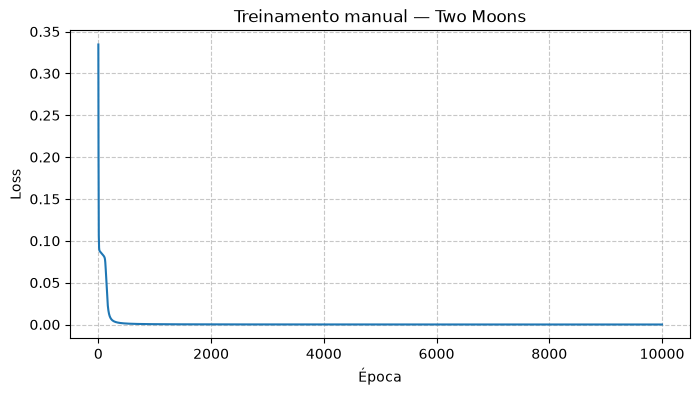

In [8]:
def train_manual(X, y, w0, b0, w1, b1, lr, epochs):
    '''Retorna os pesos treinados e a lista de losses (MSE por época).'''
    losses = []
    for epoch in range(epochs):
        grad_w0 = np.zeros_like(w0)
        grad_b0 = np.zeros_like(b0)
        grad_w1 = np.zeros_like(w1)
        grad_b1 = np.zeros_like(b1)
        loss = 0.0

        for k in range(len(X)):
            y_pred, v, a1, v4 = forward(X[k], w0, b0, w1, b1)
            loss += mse_loss(y[k, 0], y_pred)
            g_w0, g_b0, g_w1, g_b1 = backprop(X[k], y[k, 0], y_pred, a1, w0, b0, w1, b1)
            grad_w0 += g_w0
            grad_b0 += g_b0
            grad_w1 += g_w1
            grad_b1 += g_b1

        w0 -= lr * grad_w0
        b0 -= lr * grad_b0
        w1 -= lr * grad_w1
        b1 -= lr * grad_b1
        losses.append(loss / len(X))
    return w0, b0, w1, b1, losses

W0_t, b0_t, W1_t, b1_t, losses = train_manual(X, y, W0, b0, W1, b1, lr, epochs)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Treinamento manual — Two Moons')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [9]:
# Predições finais
preds = np.array([forward(X[k], W0_t, b0_t, W1_t, b1_t)[0] for k in range(len(X))])
print("Acurácia:", np.mean((preds > 0.5) == y.ravel()))
print("Loss final:", losses[-1])

Acurácia: 1.0
Loss final: 2.512662027964288e-05


## 10. Keras baseline

A mesma arquitetura `[2 → 4 → 1]` (tanh + sigmoide) foi implementada em Keras (backend torch, `seed=42`).

Compensação de taxa, como no ex01: `lr_keras = lr × N/2 = 5.0`.

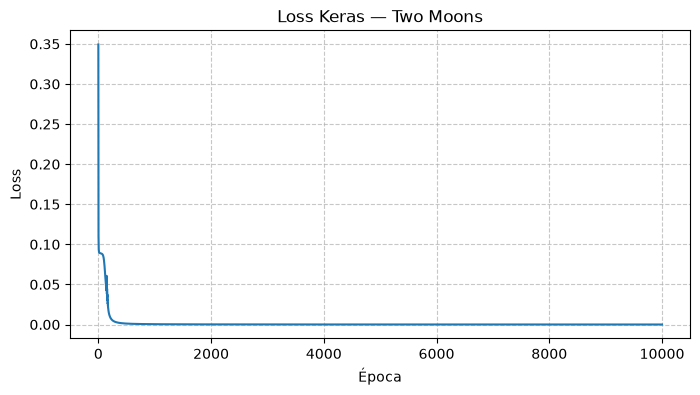

Acurácia Keras: 1.0


In [10]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import SGD

keras.utils.set_random_seed(42)

model = Sequential([
    Input(shape=(n_inputs,)),
    Dense(n_hidden, activation='tanh'),
    Dense(n_outputs, activation='sigmoid'),
])

# Mesmo ajuste do ex01: o manual SOMA os gradientes das N amostras (perda 1/2 e^2)
# e o SGD do Keras usa a média (perda e^2). Equivalência exata: lr_keras = lr * N / 2.
lr_keras = lr * len(X) / 2
model.compile(loss='mean_squared_error', optimizer=SGD(learning_rate=lr_keras),
              metrics=['accuracy'])

history = model.fit(X, y, epochs=epochs, batch_size=len(X), verbose=0)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'])
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss Keras — Two Moons')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Acurácia Keras:", model.evaluate(X, y, verbose=0)[1])

## 11. Comparação: manual vs. Keras

As duas curvas de loss lado a lado. Ambas convergem para acurácia 100% — o Keras desce um pouco antes (~época 500 vs ~800 do manual), diferença atribuída à inicialização.

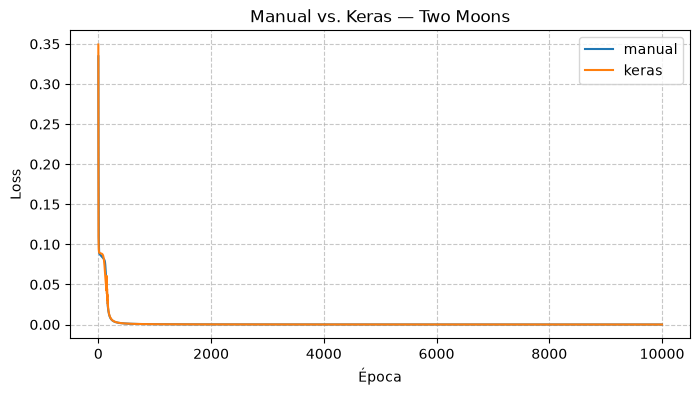

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(losses, label='manual')
plt.plot(history.history['loss'], label='keras')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Manual vs. Keras — Two Moons')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 12. Fronteira de decisão

A fronteira aprendida pela rede manual: uma região em forma de Λ envolve a lua da classe 1 e separa as duas luas — curva suave, sem erros de classificação.

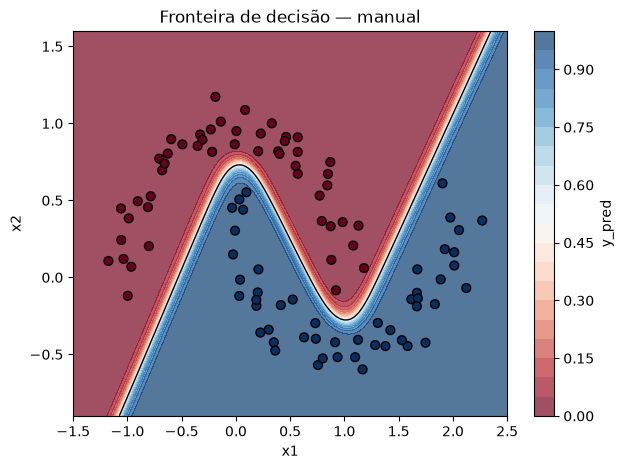

In [12]:
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 200),
                     np.linspace(-0.9, 1.6, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([forward(p, W0_t, b0_t, W1_t, b1_t)[0] for p in grid])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
plt.colorbar(label='y_pred')
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdBu',
            edgecolors='black', s=40)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1)
plt.title('Fronteira de decisão — manual')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

## 13. Anotações e conclusões

**Convergência manual.** Loss saiu de ≈ 0.33 e convergiu para ≈ 5e-5, acurácia 100%. A descida foi rápida e sem o platô de sela do ex01 — com 100 amostras, os gradientes apontam numa direção consistente desde o início.

**Soma de gradientes com N=100.** Somar 100 gradientes com `lr=0.1` não explodiu: sigmoide e tanh saturam (`|σ'| ≤ 0.25`, `|tanh'| ≤ 1`), então `e·σ'` e `e·tanh'` ficam pequenos e a soma é estável. Mesmo esquema do `exemplo4.py` (soma, não média).

**Implementação escalar passo a passo.** Forward e backprop foram escritos expandidos, uma operação por linha, 1:1 com o `formulas.txt` e com o desenho do grafo — redundante de propósito, para deixar cada gradiente visível. Convenção `w0[j, i]` (oculta, entrada), igual ao `exemplo4.py` e ao ex01.

**Derivadas.** Oculta usa `tanh'(z) = 1 - a²` (com `a = tanh(z)`); saída segue `σ'(z) = a(1-a)`. O backprop não recebe as pré-ativações: ambas as derivadas saem das saídas já calculadas (`y_pred`, `a1`).

**Manual vs. Keras.** Ambos 100% de acurácia. Para o passo ser equivalente: `lr_keras = lr × N/2 = 5.0` (Keras usa média de e²; manual soma ½e²). O Keras desceu um pouco antes nas curvas — diferença de inicialização, não de algoritmo.

**Fronteira de decisão.** As fronteiras do manual e do Keras são praticamente idênticas: uma região em forma de Λ envolve a lua da classe 1 e separa as duas luas — curva suave, sem erros. As duas implementações aprendem a mesma função.

**Comparativo com o ex01.**
- Contraste com ex01: o XOR tinha sela longa pela simetria das 4 amostras; Two Moons não — mais dados = gradiente mais informativo.
- O que muda do ex01 para cá: só a derivada da camada oculta (tanh) e a quantidade de neurônios — a estrutura do código é a mesma.
- A equivalência manual↔Keras continua exigindo compensar a taxa (`×N/2`) — mesmo efeito do ex01, agora com N=100.
- Keras com `lr=0.1` (sem compensação) também teria convergido, só bem mais devagar — diferente do XOR, aqui não há sela para travar.
